In [13]:
#add two bits : 0+0 - >0/ 0+1 -> 1/ 1+0->1 / 1+1->10
#feed forword -> all neurons connected to all neurons from next layer
#what database (input [0,0;0,1;1,0;1,1])-> output [0,0;0,1;0,1;1,0]
#how many layers (can't use one because xor is not linearly separable => 1hidden /2 hidden / 3 hidden)
#how many neurons / layer (2, 3 or 4?)
#activation function (for each layer / output - sigmoid / hidden - tanH )
#loss funstion ( binary cross entropy )

#3 such networks - compare accuracy , fasteness 
#display for the best one the weights for each layer

#n1 -> 1 hidden , 3 neurons per layer 
#n2 -> 2 hidden , 2 neurons per layer
#n3 -> 3 hidden , 1 neurons per layer

#input -> h1 (tanH)-> h2 (tanH)-> h3 (tanH)-> output (no activation as we use binary cross entropy loss function)

#BCEWithLogitsLoss() uses sigmoid
#correct_samples = (predictions == labels).all(dim=1)
#accuracy = correct_samples.float().mean()



clasify points in two regions - separated by a line -> combine them in network 

linear models limited , we need non-linear to optimize !

chose a dif activ function than a LU
ensure gradients remain large through hidden unit !

common (sigmoid/relu/leaky/Relu/maxout/soft/swish)

manually engineer - map to higher dimensional space

tanH not good for outputs outside -1,1 
sig not good for outputs outside 0,1
tanH and sig can be cut in pieces for multi-class evaluation

relu -> non-vanishing grad for x>0 -> sparsity for negative values 
leaky relu -> non-zero grad for negative numbers (not always consistent)

generalized relu -> param outside the max 
softplus = relu + sigmoid 
swish same 

we don't want corners - we want softness !!!


loos fct : likelihood - same for all measurements 
maximize likelihood (log likelihood)

mean abs loss -> abs between what we want and what we have -> bad for outliars (drag tha optimization/grad  in one direction )
mean sqare error  -> ?
cross-entropy -> diff between two prob distrib 

better to go in depth -> many layers 

propagate the backward error and modify weights , add w-n*grad w * entrance  (requires to derivate the fct)

compute the derivative of error for every single weight


In [1]:
import torch as t
import torch.nn as nn
from collections import OrderedDict
import time
import matplotlib.pyplot as plt

In [15]:
# your code here
#model1 = nn.Sequential(OrderedDict([
#    ('hidden', nn.
#]))

In [2]:
model1 = nn.Sequential(OrderedDict([
    ('h1', nn.Linear(2, 3)),
    ('act1', nn.Tanh()),
    ('out', nn.Linear(3, 2))
]))

In [3]:
model2 = nn.Sequential(OrderedDict([
    ('h1', nn.Linear(2, 2)),
    ('act1', nn.Tanh()),
    ('h2', nn.Linear(2, 2)),
    ('act2', nn.Tanh()),
    ('out', nn.Linear(2, 2))
]))

In [4]:
model3 = nn.Sequential(OrderedDict([
    ('h1', nn.Linear(2, 4)),
    ('act1', nn.Tanh()),
    ('h2', nn.Linear(4, 4)),
    ('act2', nn.Tanh()),
    ('h3', nn.Linear(4, 4)),
    ('act3', nn.Tanh()),
    ('h4', nn.Linear(4, 4)),
    ('act4', nn.Tanh()),
    ('out', nn.Linear(4, 2))
]))

In [5]:
# your code here
#data_in = torch.tensor( ...
data_in=t.tensor([
    [0.,0.],
    [0.,1.],
    [1.,0.],
    [1.,1.]
]
)
print(data_in)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])


In [6]:
# your code here
# data_target = torch.tensor( ...
data_target=t.tensor([
    [0.,0.],
    [0.,1.],
    [0.,1.],
    [1.,0.]
])
print(data_target)

tensor([[0., 0.],
        [0., 1.],
        [0., 1.],
        [1., 0.]])


In [7]:
def train_model(model, epochs=2000):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = t.optim.SGD(model.parameters(), lr=0.1)

    losses = []
    accs = []

    epoch_reached_1 = None 

    for epoch in range(epochs):
        outputs = model(data_in)
        loss = criterion(outputs, data_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = (t.sigmoid(outputs) > 0.5).float()
        correct = (preds == data_target).all(dim=1)
        acc = correct.float().mean()

        losses.append(loss.item())
        accs.append(acc.item())

        if acc.item() == 1.0 and epoch_reached_1 is None:
            epoch_reached_1 = epoch

    return losses, accs, epoch_reached_1

In [8]:
loss1, acc1, fast1 = train_model(model1)

print("Final accuracy model1:", acc1[-1])

Final accuracy model1: 1.0


In [9]:
loss2, acc2, fast2 = train_model(model2)

print("Final accuracy model2:", acc2[-1])

Final accuracy model2: 1.0


In [10]:
loss3, acc3, fast3 = train_model(model3)

print("Final accuracy model3:", acc3[-1])

Final accuracy model3: 1.0


In [11]:
print("\nSpeed comparison (epoch when acc = 1)")

print("Model 1:", fast1 if fast1 is not None else "Did not reach 1.0")
print("Model 2:", fast2 if fast2 is not None else "Did not reach 1.0")
print("Model 3:", fast3 if fast3 is not None else "Did not reach 1.0")


Speed comparison (epoch when acc = 1)
Model 1: 911
Model 2: 1239
Model 3: 1304


first try : m1 -> ac 1, m2-> ac 1, m3 -> ac 1 (m1 fastest)
second try : m1->1, m2->0,75, m3->1 (m1 fastest)
third try : m1->1, m2->0,75, m3->0,75 (m1 fastest)
forth try : m1->1 , m2-> 0,5, m3->1 (m3 fastest diff of ~500)
fifth try : m1->1, m2->0,5, m3->1 (m3 fastest diff of ~200)
sixth try : m1->1, m2->0,75, m3-> 1 (m1 fastest diff of ~500)


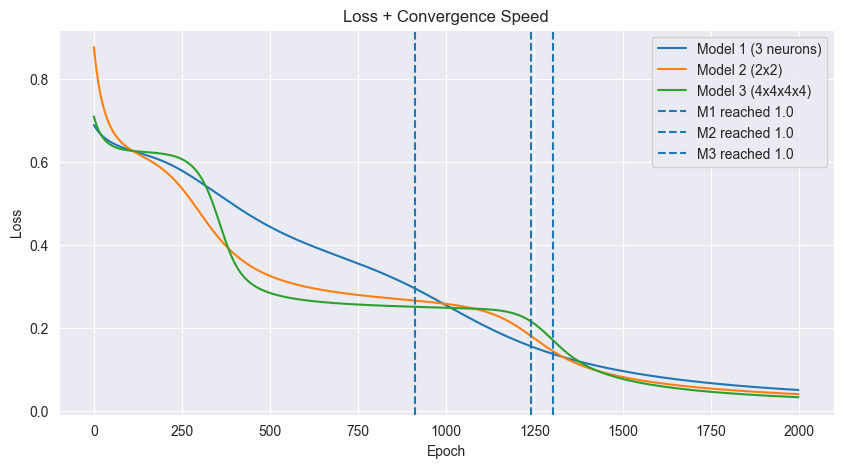

In [12]:
plt.figure(figsize=(10,5))

plt.plot(loss1, label="Model 1 (3 neurons)")
plt.plot(loss2, label="Model 2 (2x2)")
plt.plot(loss3, label="Model 3 (4x4x4x4)")

if fast1 is not None:
    plt.axvline(fast1, linestyle='--', label="M1 reached 1.0")
if fast2 is not None:
    plt.axvline(fast2, linestyle='--', label="M2 reached 1.0")
if fast3 is not None:
    plt.axvline(fast3, linestyle='--', label="M3 reached 1.0")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss + Convergence Speed")
plt.legend()
plt.show()

In [13]:
def print_weights(model, name):
    print(f"\n{name} weights:\n")
    for param_name, param in model.named_parameters():
        print(param_name)
        print(param.data)
        print()

# Put models and their speeds in a list
models_info = [
    ("Model 1", model1, fast1),
    ("Model 2", model2, fast2),
    ("Model 3", model3, fast3)
]

# Filter only models that reached accuracy 1
valid_models = [m for m in models_info if m[2] is not None]

if len(valid_models) == 0:
    print("No model reached accuracy 1.0")
else:
    # pick the fastest (smallest epoch)
    best_model_name, best_model, best_speed = min(valid_models, key=lambda x: x[2])

    print(f"\nBest model: {best_model_name}")
    print(f"Reached accuracy 1.0 at epoch: {best_speed}")

    print_weights(best_model, best_model_name)


Best model: Model 1
Reached accuracy 1.0 at epoch: 911

Model 1 weights:

h1.weight
tensor([[-2.3777, -2.5652],
        [-0.8378, -0.2853],
        [-2.4573, -2.4941]])

h1.bias
tensor([1.1638, 1.2088, 3.6549])

out.weight
tensor([[-2.0560, -1.7329, -3.7651],
        [-3.2050, -0.6335,  3.3782]])

out.bias
tensor([-1.8100, -2.4648])

